# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [38]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

In [39]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [40]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [41]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

El conjunto de datos no presenta valores faltantes; sin embargo, algunas variables requieren ajuste en su tipo de dato para representar correctamente su naturaleza y facilitar el análisis estadístico y la validación de hipótesis.

| Variable | Tipo actual esperado | Tipo recomendado | Justificación |
|---|---|---|---|
| `date` | `object` | `datetime` | Representa fechas y debe convertirse para análisis temporal. |
| `landing` | `object` | `category` | Variable categórica que identifica la versión de la página (`A`, `B`). |
| `region` | `object` | `category` | Representa categorías geográficas. |
| `dispositivo` | `object` | `category` | Variable categórica del tipo de dispositivo. |
| `traffic_source` | `object` | `category` | Canal de adquisición del usuario. |
| `user_type` | `object` | `category` | Clasificación categórica del usuario. |
| `converted` | `int64` | `bool` o `category` | Variable binaria que indica conversión (`0` o `1`). |


In [42]:
# Cambiar las fechas a valores datetime
df['date'] = pd.to_datetime(df['date'])

In [43]:
# Cambiar el tipo de dato a categoricos.
categoricas = [
    'landing',
    'region',
    'dispositivo',
    'traffic_source',
    'user_type',
    'converted'
]

for col in categoricas:
    df[col] = df[col].astype('category')


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  category      
 3   region          40000 non-null  category      
 4   dispositivo     40000 non-null  category      
 5   traffic_source  40000 non-null  category      
 6   user_type       40000 non-null  category      
 7   converted       40000 non-null  category      
 8   gasto           40000 non-null  float64       
dtypes: category(6), datetime64[ns](1), float64(1), object(1)
memory usage: 1.1+ MB


In [45]:
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [46]:
duplicados = df['user_id'].duplicated().sum()
print('Usuarios repetidos:', duplicados)

Usuarios repetidos: 0


 **Variable `date`**  
Explorar rango de fechas

In [47]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [48]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [49]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [50]:
# Resumen estadístico de usuarios que se convirtieron
df["converted"].describe()

count     40000
unique        2
top           0
freq      34294
Name: converted, dtype: int64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [51]:
categoricas = [
    'landing',
    'region',
    'dispositivo',
    'traffic_source',
    'user_type',
    'converted'
]

In [52]:
# Explorar variables categóricas y cómo se distribuyen
for col in categoricas:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())


--- landing ---
B    20018
A    19982
Name: landing, dtype: int64

--- region ---
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

--- dispositivo ---
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

--- traffic_source ---
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

--- user_type ---
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64

--- converted ---
0    34294
1     5706
Name: converted, dtype: int64


In [53]:
for col in categoricas:
    print(f'\n--- {col} (%) ---')
    print(df[col].value_counts(normalize=True) * 100)


--- landing (%) ---
B    50.045
A    49.955
Name: landing, dtype: float64

--- region (%) ---
Norte        27.9150
Centro       24.0325
Sur          20.0975
Occidente    15.9950
Oriente      11.9600
Name: region, dtype: float64

--- dispositivo (%) ---
Mobile     62.0725
Desktop    37.9275
Name: dispositivo, dtype: float64

--- traffic_source (%) ---
Organic     44.9675
Ads         29.8375
Email       15.3075
Referral     9.8875
Name: traffic_source, dtype: float64

--- user_type (%) ---
Nuevo         65.0825
Recurrente    34.9175
Name: user_type, dtype: float64

--- converted (%) ---
0    85.735
1    14.265
Name: converted, dtype: float64


## Análisis inicial de calidad de datos

- El conjunto de datos contiene **40,000 registros** y **9 variables**.
- No se identificaron valores nulos en ninguna de las columnas.
- Las variables categóricas (`landing`, `region`, `dispositivo`, `traffic_source`, `user_type` y `converted`) presentan categorías válidas y consistentes.
- La columna `date` fue reconocida correctamente como tipo fecha.
- La columna `gasto` contiene únicamente valores numéricos y no presenta valores negativos.

### Observaciones sobre la variable `gasto`

La distribución de la variable `gasto` se encuentra fuertemente sesgada hacia la derecha:

- El 25%, 50% y 75% de los registros tienen un gasto igual a 0.
- La media es de 9.33 unidades monetarias.
- El valor máximo observado es de 303.68.

Esto indica que la mayoría de los usuarios no realizó gastos, mientras que una pequeña proporción registró montos relativamente altos. Este comportamiento es común en experimentos de conversión y comercio electrónico.

### Conclusión

No se identificaron errores evidentes en la estructura de los datos ni valores fuera de rango. Todas las columnas contienen valores esperados, por lo que es posible continuar con el análisis exploratorio y la validación de hipótesis.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [54]:
# Gasto por versión
gasto_A = df[df['landing'] == 'A']['gasto']
gasto_B = df[df['landing'] == 'B']['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(19982, 20018)

### 3.1. Prueba de hipótesis para el gasto promedio

**Hipótesis**

**Hipótesis nula (H₀):**  
El gasto promedio de los usuarios es el mismo en ambas versiones de la página.


$$
H_0: \mu_A = \mu_B
$$

**Hipótesis alternativa (H₁):**  
El gasto promedio de los usuarios es diferente entre las versiones de la página.

$$
H_1 : \mu_A \neq \mu_B
$$

**Nivel de significancia**

Se utilizará un nivel de significancia de:

$$
\alpha = 0.05
$$

**Criterio de decisión**

- Si el valor p es menor que 0.05, se rechaza la hipótesis nula.
- Si el valor p es mayor o igual a 0.05, no se rechaza la hipótesis nula.

**Prueba estadística**

Se aplicará una prueba t para dos muestras independientes con el objetivo de determinar si existe una diferencia estadísticamente significativa en el gasto promedio entre los usuarios expuestos a la versión A y los expuestos a la versión B.

In [55]:
# Aplicar prueba
stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico: {stat}")
print(f"Valor p: {p_value}")

Estadístico: -12.84131999696572
Valor p: 1.142258400461568e-37


In [56]:
alpha_0 = 0.05

if p_value < alpha_0:
    print("Se rechaza la hipótesis nula.")
else:
    print("No se rechaza la hipótesis nula.")

Se rechaza la hipótesis nula.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀).

**Interpretación de negocio:**  
Los resultados indican que existe una diferencia estadísticamente significativa en el gasto promedio entre los usuarios que visitaron la página A y los que visitaron la página B. Esto sugiere que la versión de la página mostrada a los usuarios influye en el monto gastado.

Debido a que se rechazó la hipótesis nula, la diferencia observada en los promedios no puede atribuirse únicamente al azar. Por lo tanto, existe evidencia estadística para afirmar que ambas versiones generan comportamientos de gasto distintos.

Para determinar cuál versión es más efectiva desde el punto de vista comercial, es necesario comparar los promedios de gasto de los grupos A y B.


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba de hipótesis para la tasa de conversión

**Hipótesis:**

- **Hipótesis nula (H₀):** La tasa de conversión es la misma en la página A y la página B.

$$
H_0: p_A = p_B
$$

- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre la página A y la página B.

$$
H_1: p_A \neq p_B
$$

**Nivel de significancia**

$$
\alpha = 0.05
$$

**Criterio de decisión**

- Si el valor p < 0.05, se rechaza la hipótesis nula.
- Si el valor p ≥ 0.05, no se rechaza la hipótesis nula.

**Prueba estadística**

Se aplicará una prueba de diferencia de proporciones para comparar la tasa de conversión entre los usuarios expuestos a la página A y los usuarios expuestos a la página B. El objetivo es determinar si la versión de la página tiene un efecto significativo sobre la probabilidad de conversión.

In [57]:
# Número de usuarios convertidos por página
convertidos = df[df['converted'] == 1].groupby('landing')['user_id'].count()

# Total de usuarios por página
totales = df.groupby('landing')['user_id'].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: user_id, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: user_id, dtype: int64


In [58]:
conversiones = pd.crosstab(df['landing'], df['converted'])

print(conversiones)

converted      0     1
landing               
A          17470  2512
B          16824  3194


In [59]:
# Número de conversiones
count = [2512, 3194]

# Número total de usuarios
nobs = [19982, 20018]

# Aplicar prueba
stat, p_value = proportions_ztest(count, nobs)

# Visualizar resultados
print(f"Estadístico: {stat}")
print(f"Valor p: {p_value}")

Estadístico: -9.677362674655983
Valor p: 3.7629765627523803e-22


In [60]:

alpha_1 = 0.05

if p_value < alpha_1:
    print("Se rechaza la hipótesis nula.")
else:
    print("No se rechaza la hipótesis nula.")


Se rechaza la hipótesis nula.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀).

**Interpretación de negocio:**  
Los resultados indican que existe una diferencia estadísticamente significativa en la tasa de conversión entre la página A y la página B. Esto significa que la versión de la página mostrada a los usuarios influye en la probabilidad de que estos realicen una conversión.

Al comparar las tasas de conversión observadas, la página B presenta un mejor desempeño que la página A. La página A alcanzó una tasa de conversión aproximada de 12.57%, mientras que la página B obtuvo una tasa cercana al 15.96%.

Por lo tanto, existe evidencia estadística para concluir que la página B genera más conversiones que la página A. Desde una perspectiva de negocio, la implementación de la página B podría incrementar el número de usuarios convertidos y mejorar el rendimiento general del sitio.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba de independencia Chi-cuadrado

**Hipótesis:**

- **Hipótesis nula (H₀):** La fuente de tráfico y la conversión son variables independientes; no existe asociación entre el canal de adquisición y la probabilidad de conversión.

$$
H_0:\ \text{traffic\_source y converted son independientes}
$$

- **Hipótesis alternativa (H₁):** La fuente de tráfico y la conversión no son variables independientes; existe una asociación entre el canal de adquisición y la probabilidad de conversión.

$$
H_1:\ \text{traffic\_source y converted no son independientes}
$$

**Nivel de significancia**

$$
\alpha = 0.05
$$

**Criterio de decisión**

- Si el valor p < 0.05, se rechaza la hipótesis nula.
- Si el valor p ≥ 0.05, no se rechaza la hipótesis nula.

In [61]:
# Aplicar prueba
# Tabla de contingencia
tabla = pd.crosstab(df['traffic_source'], df['converted'])

# Aplicar prueba
chi2, p_value, dof, expected = chi2_contingency(tabla)

# Visualizar resultados
print(tabla)
print("------------------------")
print(f"Estadístico Chi-cuadrado: {chi2}")
print(f"Valor p: {p_value}")
print(f"Grados de libertad: {dof}")


converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549
------------------------
Estadístico Chi-cuadrado: 8.662108841397938
Valor p: 0.0341375947833914
Grados de libertad: 3


In [62]:

alpha_2 = 0.05

if p_value < alpha_2:
    print("Se rechaza la hipótesis nula.")
else:
    print("No se rechaza la hipótesis nula.")


Se rechaza la hipótesis nula.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀).

**Interpretación de negocio:**  
La prueba Chi-cuadrado arrojó un valor p de 0.0341, inferior al nivel de significancia de 0.05. Por lo tanto, existe evidencia estadística suficiente para concluir que la fuente de tráfico y la conversión no son independientes. Esto significa que el canal por el que llegan los usuarios influye en la probabilidad de conversión.

Al analizar las conversiones por canal, se observa que:

- **Organic** generó la mayor cantidad de conversiones (2480), seguido de **Ads** (1759), **Email** (918) y **Referral** (549).
- Sin embargo, al considerar las tasas de conversión:
  - **Email:** 918 / 6123 ≈ **14.99%**
  - **Referral:** 549 / 3955 ≈ **13.88%**
  - **Organic:** 2480 / 17987 ≈ **13.79%**
  - **Ads:** 1759 / 11935 ≈ **14.74%**

Las diferencias en las tasas de conversión indican que algunos canales son más eficientes que otros para convertir visitantes en clientes. Aunque Organic aporta el mayor volumen de conversiones debido a su alto número de usuarios, Email presenta la tasa de conversión más alta, lo que sugiere una mayor efectividad para generar conversiones.

Desde una perspectiva de negocio, estos resultados sugieren que la estrategia de adquisición puede optimizarse analizando no solo el volumen de tráfico generado por cada canal, sino también su capacidad para convertir usuarios. Los canales con mayores tasas de conversión podrían representar oportunidades para incrementar el rendimiento de las campañas de marketing.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba de independencia Chi-cuadrado

**Hipótesis:**

- **Hipótesis nula (H₀):** El tipo de usuario (`user_type`) y la conversión (`converted`) son variables independientes; el tipo de usuario no influye en la probabilidad de conversión.

$$
H_0:\ \text{user\_type y converted son independientes}
$$

- **Hipótesis alternativa (H₁):** El tipo de usuario (`user_type`) y la conversión (`converted`) no son variables independientes; existe una asociación entre el tipo de usuario y la probabilidad de conversión.

$$
H_1:\ \text{user\_type y converted no son independientes}
$$

**Nivel de significancia**

$$
\alpha = 0.05
$$

**Criterio de decisión**

- Si el valor p < 0.05, se rechaza la hipótesis nula.
- Si el valor p ≥ 0.05, no se rechaza la hipótesis nula.

In [63]:
# Aplicar prueba
# Tabla de contingencia
tabla_user = pd.crosstab(df['user_type'], df['converted'])

print(tabla_user)

# Aplicar prueba
chi2, p_value, dof, expected = chi2_contingency(tabla_user)

# Visualizar resultados
print("\n------------------------")
print(f"Estadístico Chi-cuadrado: {chi2}")
print(f"Valor p: {p_value}")
print(f"Grados de libertad: {dof}")


converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968

------------------------
Estadístico Chi-cuadrado: 0.5134849494478645
Valor p: 0.4736341272301974
Grados de libertad: 1


In [64]:
alpha_3 = 0.05

if p_value < alpha_3:
    print("Se rechaza la hipótesis nula.")
else:
    print("No se rechaza la hipótesis nula.")

No se rechaza la hipótesis nula.


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula (H₀).

**Interpretación de negocio:**  
La prueba Chi-cuadrado produjo un valor p de 0.4736, superior al nivel de significancia de 0.05. Por lo tanto, no existe evidencia estadística suficiente para afirmar que el tipo de usuario (`user_type`) esté asociado con la conversión (`converted`).

Al analizar las tasas de conversión:

- **Usuarios nuevos:** 3738 / 26033 ≈ **14.36%**
- **Usuarios recurrentes:** 1968 / 13967 ≈ **14.09%**

Las tasas de conversión son muy similares entre ambos grupos, con una diferencia de apenas 0.27 puntos porcentuales. Aunque los usuarios nuevos generaron un mayor número absoluto de conversiones, esto se debe principalmente a que representan una mayor proporción de la muestra.

Desde una perspectiva de negocio, los resultados sugieren que ser un usuario nuevo o recurrente no tiene un impacto significativo en la probabilidad de conversión dentro de este conjunto de datos. Por lo tanto, no existe evidencia para diseñar estrategias diferenciadas basadas únicamente en esta clasificación de usuarios.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

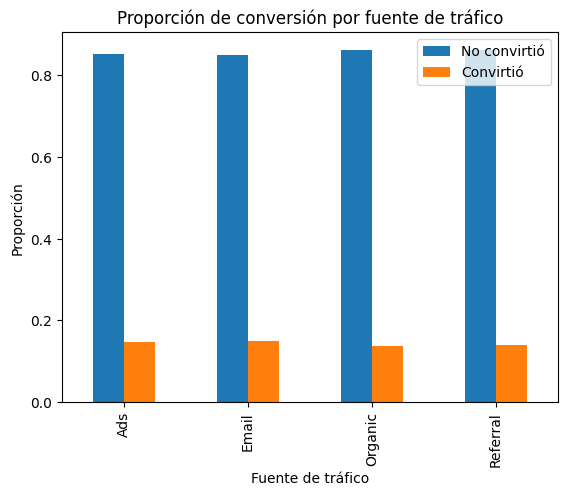

In [65]:
tabla_traffic_prop = pd.crosstab(
    df['traffic_source'],
    df['converted'],
    normalize='index'
)

tabla_traffic_prop.plot(kind='bar')

plt.title('Proporción de conversión por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Proporción')
plt.legend(['No convirtió', 'Convirtió'])
plt.show()

### Interpretación: Proporción de conversión por fuente de tráfico

El gráfico muestra que las tasas de conversión difieren ligeramente entre las distintas fuentes de tráfico. Los canales **Email** y **Ads** presentan las proporciones de conversión más altas, mientras que **Organic** muestra la más baja.

Aunque las diferencias visuales son moderadas, la prueba Chi-cuadrado realizada anteriormente indicó una asociación estadísticamente significativa entre la fuente de tráfico y la conversión (p < 0.05). Esto sugiere que el canal de adquisición influye en la probabilidad de que un usuario convierta.

Desde una perspectiva de negocio, no solo es importante considerar el volumen de usuarios que aporta cada canal, sino también su capacidad para generar conversiones. Los resultados indican que algunos canales son más eficientes que otros para convertir visitantes en clientes.

### Relación entre el tipo de usuario y la conversión

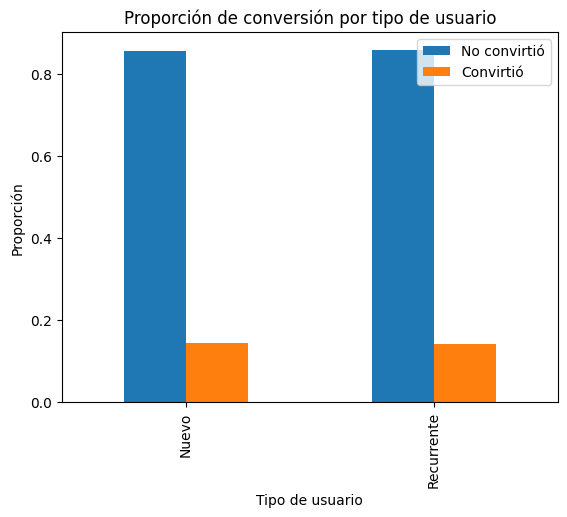

In [66]:
tabla_user_prop = pd.crosstab(
    df['user_type'],
    df['converted'],
    normalize='index'
)

tabla_user_prop.plot(kind='bar')

plt.title('Proporción de conversión por tipo de usuario')
plt.xlabel('Tipo de usuario')
plt.ylabel('Proporción')
plt.legend(['No convirtió', 'Convirtió'])
plt.show()

### Interpretación: Proporción de conversión por tipo de usuario

El gráfico muestra que las tasas de conversión de los usuarios nuevos y recurrentes son muy similares. Ambos grupos presentan una proporción de conversión cercana al 14%, sin diferencias visuales relevantes.

Este resultado es consistente con la prueba Chi-cuadrado realizada previamente, la cual no encontró evidencia estadísticamente significativa de una asociación entre el tipo de usuario y la conversión (p > 0.05).

Desde el punto de vista de negocio, los resultados sugieren que ser un usuario nuevo o recurrente no modifica de forma importante la probabilidad de conversión dentro de este conjunto de datos. Por lo tanto, no existe evidencia suficiente para justificar estrategias diferenciadas basadas únicamente en esta clasificación.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

## 8.1.1 Comparación de página (A vs B)

### Gasto promedio por usuario que convirtió

La prueba t de Student para muestras independientes arrojó un valor p menor a 0.05, por lo que se rechaza la hipótesis nula. Existe una diferencia estadísticamente significativa en el gasto promedio entre ambas versiones.

La distribución del gasto está fuertemente sesgada hacia la derecha, ya que el 75% de los usuarios registró un gasto de $0. Esto indica que el gasto total proviene principalmente de una minoría de usuarios que realizaron conversiones. Los resultados sugieren que la Página B captura una proporción mayor y más valiosa de este segmento.

**Interpretación:** La versión de la página influye directamente en el comportamiento de gasto de los usuarios. Dado que la Página B genera más conversiones y presenta una diferencia significativa en el gasto promedio, existe evidencia para concluir que produce un mayor valor económico por usuario expuesto.

### Tasa de conversión

La Página A alcanzó una tasa de conversión aproximada de 12.57% (2,512 conversiones de 19,982 usuarios), mientras que la Página B alcanzó una tasa cercana al 15.96% (3,194 conversiones de 20,018 usuarios), lo que representa una diferencia de 3.39 puntos porcentuales.

La prueba Z de proporciones confirmó que esta diferencia es estadísticamente significativa (p < 0.05), por lo que es poco probable que haya ocurrido por azar.

**Interpretación:** La Página B convierte aproximadamente un 27% más usuarios que la Página A. Considerando que ambos grupos tienen tamaños prácticamente idénticos, la evidencia es sólida y respalda la adopción de la Página B como la versión más efectiva.

## 8.1.2 Segmentación por fuente de tráfico

La prueba Chi-cuadrado encontró una asociación estadísticamente significativa entre la fuente de tráfico y la conversión (p = 0.034 < 0.05).

Las tasas de conversión observadas fueron:

- Email: 14.99%
- Ads: 14.74%
- Referral: 13.88%
- Organic: 13.79%

Aunque Organic generó la mayor cantidad absoluta de conversiones (2,480), también fue el canal con mayor volumen de tráfico (17,987 usuarios). Por ello, su liderazgo en conversiones se explica principalmente por el tamaño de la audiencia y no por una mayor eficiencia.

**Interpretación:** El canal de adquisición no solo determina cuántos usuarios llegan al sitio, sino también la calidad de dichos usuarios. Los visitantes provenientes de Email presentan la mayor probabilidad de conversión, lo que sugiere una mejor alineación entre el mensaje de marketing y las necesidades del usuario. Estos resultados resaltan la importancia de distinguir entre volumen de tráfico y eficiencia de conversión.

## 8.1.3 Segmentación por tipo de usuario

La prueba Chi-cuadrado no encontró evidencia de una asociación estadísticamente significativa entre el tipo de usuario y la conversión (p = 0.4736 > 0.05). Por lo tanto, no se rechaza la hipótesis nula.

Las tasas de conversión observadas fueron:

- Usuarios nuevos: 14.36%
- Usuarios recurrentes: 14.09%

La diferencia entre ambos grupos es de apenas 0.27 puntos porcentuales, lo que indica un comportamiento muy similar.

**Interpretación:** El historial previo del usuario no parece influir de manera significativa en la probabilidad de conversión dentro de este experimento. Tanto los usuarios nuevos como los recurrentes responden de forma similar a las versiones de la página evaluadas, lo que sugiere que otros factores, como el diseño de la landing page o el canal de adquisición, tienen un impacto mayor en el desempeño observado.

## 8.1.4 Recomendaciones de negocio

### Adoptar la Página B como versión definitiva

La evidencia estadística muestra que la Página B supera consistentemente a la Página A tanto en tasa de conversión como en generación de valor económico. Su implementación permitiría incrementar el número de conversiones y mejorar el rendimiento general del sitio.

### Incrementar la inversión en Email y Ads

Los canales Email y Ads presentan las tasas de conversión más elevadas del análisis. Una mayor asignación de presupuesto hacia estos canales podría aumentar la eficiencia de las campañas y maximizar el retorno sobre la inversión.

### Optimizar el canal Organic

Aunque Organic aporta el mayor volumen de tráfico y conversiones, presenta la tasa de conversión más baja. Esto representa una oportunidad para mejorar el rendimiento mediante optimizaciones en SEO, contenido, experiencia de usuario o mensajes dirigidos a este segmento.

### Evitar segmentaciones basadas únicamente en el tipo de usuario

Dado que no se encontraron diferencias significativas entre usuarios nuevos y recurrentes, no se recomienda priorizar estrategias de personalización basadas exclusivamente en esta variable. Los esfuerzos de optimización deberían enfocarse en factores con mayor capacidad explicativa, como la versión de la página y la fuente de tráfico.